In [1]:
from pathlib import Path
import subprocess

from IPython.display import SVG, display

PROJECT_DIR = Path.cwd()
if not (PROJECT_DIR / "bin").is_dir():
    PROJECT_DIR = PROJECT_DIR.parent

DATABASE_PATH = PROJECT_DIR / "local_data" / "ani_microbial_eukaryotes.duckdb"
R_SCRIPT = PROJECT_DIR / "bin" / "figure3_ani_ridgeline_by_genus.R"
R_BIN = Path.home() / ".cache/conda-envs/ani-microbial-eukaryotes-notebook/bin/Rscript"
if not R_BIN.is_file():
    R_BIN = Path("/home/bin/Rscript")

for required_path in (DATABASE_PATH, R_SCRIPT, R_BIN):
    if not required_path.is_file():
        raise FileNotFoundError(required_path)

FIGS_DIR = PROJECT_DIR / "assets" / "figures"
FIGS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE3_PREFIX = FIGS_DIR / "fig-3"
FIGURE3_SVG = FIGURE3_PREFIX.with_suffix(".svg")

print(f"Analysis database: {DATABASE_PATH}")

Analysis database: /scicomp/home-pure/rqu4/.local/share/proj/ANI-microbial-eukaryotes-hetrick-2026/new_clone/ANI-microbial-eukaryotes-hetrick-2026/local_data/ani_microbial_eukaryotes.duckdb


Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.482
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.18
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
Picking joint bandwidth of 0.0699
Picking joint bandwidth of 0.204
Picking joint bandwidth of 0.6
Warning message:
Removed 6 rows containing non-finite outside the scale range
(`stat_density_ridges()`). 
Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.482
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.18
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
Picking joint bandwidth of 0.0699
Picking joint bandwidth of 0.204
Picking joint bandwidth of 0.6
Warning message:
Removed 6 rows containing non-finite outside the scale range
(`stat_density_ridges()`). 
Picking joint bandwidth of 0.192
Picking joint bandwidth of 0.482
Picking joint bandwidth of 0.454
Picking joint bandwidth of 1.18
Picking joint bandwidth of 0.142
Picking joint bandwidth of 0.485
P

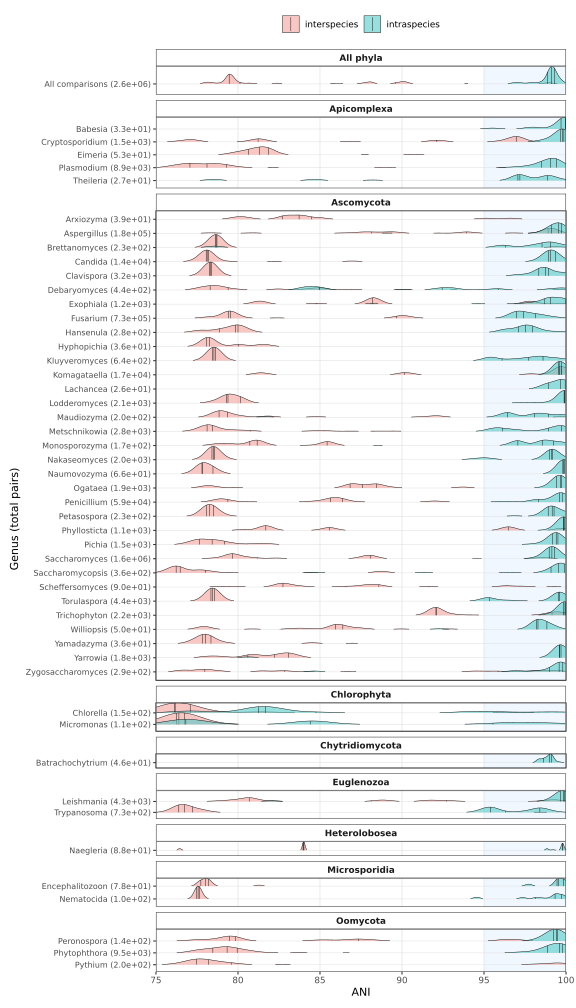

In [2]:
command = [
    str(R_BIN),
    str(R_SCRIPT),
    "--repo-root", str(PROJECT_DIR),
    "--database", str(DATABASE_PATH),
    "--output-prefix", str(FIGURE3_PREFIX),
]
result = subprocess.run(command, check=True, text=True, capture_output=True)
if result.stdout.strip():
    print(result.stdout)
if result.stderr.strip():
    print(result.stderr)
display(SVG(filename=str(FIGURE3_SVG)))